In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import jax

import os
os.environ["JAX_PLATFORMS"] = "cpu"
print("JAX devices:", jax.devices())


import sys
sys.path.append('./')
import JAXdata_loaders
import JAXdata_loaders_seasonal

from importlib import reload
JAXdata_loaders = reload(JAXdata_loaders)
JAXdata_loaders_seasonal = reload(JAXdata_loaders_seasonal)


JAX devices: [CpuDevice(id=0)]


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
#!/usr/bin/env python

# Core Libraries
import inox                  # Custom library (likely for modeling and random utilities)
inox = reload(inox)
import inox.nn as nn         # Neural network components
import jax                   # JAX for high-performance computing
import optax                 # Optimizers for JAX
import wandb                 # Weights and Biases for experiment tracking

# Data handling
#from datasets import Array3D, Features, load_from_disk
import sys
sys.path.append('./')
import JAXdata_loaders


# Workflow management
from dawgz import job, schedule

# Utils
from functools import partial
from tqdm import trange
from typing import *
from utils import *          # Assumed utility functions (augmentations, flatten, sampling, etc.)


# Dataloaders in JAX

To replicate the behavior of your PyTorch ConcatDataset, random_split, and DataLoader with custom samplers in JAX, we need to reimplement a few components using NumPy/JAX primitives. JAX does not have a native dataloader abstraction like PyTorch, so we handle batching, shuffling, and iteration manually.

Here’s a drop-in JAX-style equivalent:



In [5]:
import warnings
import os
import numpy as np
import zarr
from tqdm import tqdm
from pathlib import Path


In [6]:
from importlib import reload
JAXdata_loaders_seasonal = reload(JAXdata_loaders_seasonal)

standards = {
                "mean_ssh": 0.0, "std_ssh": 0.1,
                "mean_sst": 15.956900367755182, "std_sst": 5.987649544923141,
                "extra_mean_tuning": 1.5,
            }




In [7]:
class PrecomputeDatasetWriter:
    def __init__(self, dataset, out_dir, format="npz", compression="blosc"):
        self.dataset = dataset
        self.out_dir = Path(out_dir)
        self.format = format
        self.compression = compression
        self.out_dir.mkdir(parents=True, exist_ok=True)

    def write(self):
        if self.format == "npz":
            for i in tqdm(range(len(self.dataset)), desc="Precomputing .npz"):
                sample = self.dataset[i]
                np.savez_compressed(self.out_dir / f"sample_{i:05d}.npz", **sample)
        elif self.format == "zarr":
            first = self.dataset[0]
            root = zarr.open_group(str(self.out_dir), mode="w")
            zarr_sets = {
                k: root.create_dataset(
                    k,
                    shape=(len(self.dataset), *v.shape),
                    chunks=(1, *v.shape),
                    dtype=v.dtype,
                    compressor=zarr.Blosc(cname=self.compression)  # ✅ specify cname explicitly
                ) for k, v in first.items()
            }
            for i in tqdm(range(len(self.dataset)), desc="Precomputing .zarr"):
                sample = self.dataset[i]
                for k, v in sample.items():
                    root[k][i] = np.array(v)  # convert jax array to numpy
        else:
            raise ValueError(f"Unsupported format: {self.format}")


In [7]:
import jax.numpy as jnp
from glob import glob

class PrecomputedJAXDataset:
    def __init__(self, source, format="npz"):
        self.format = format
        self.source = source
        if format == "npz":
            self.paths = sorted(glob(f"{source}/sample_*.npz"))
            self.length = len(self.paths)
        elif format == "zarr":
            self.zarr = zarr.open_group(str(source), mode="r")
            self.length = len(next(iter(self.zarr.values())))
        else:
            raise ValueError(f"Unsupported format: {format}")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.format == "npz":
            arrays = np.load(self.paths[idx])
            return {k: jnp.array(v) for k, v in arrays.items()}
        elif self.format == "zarr":
            return {k: jnp.array(self.zarr[k][idx]) for k in self.zarr}



In [16]:
cached_ds = PrecomputedJAXDataset("/home/tm3076/vast/priors_precomputed_datasets/precomputed_data_sst/sst_crho_0.4/train", format="zarr")
sample = cached_ds[:1000]  # {'y': ..., 'A': ...} as jnp arrays

In [17]:
len(cached_ds)

17412

In [8]:
cloud_rhos = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

for cloud_rho in cloud_rhos:
    output_dir = f"/vast/tm3076/precomputed_data_sst/sst_crho_{cloud_rho}"
    print(output_dir)

/vast/tm3076/precomputed_data_sst/sst_crho_0.1
/vast/tm3076/precomputed_data_sst/sst_crho_0.2
/vast/tm3076/precomputed_data_sst/sst_crho_0.3
/vast/tm3076/precomputed_data_sst/sst_crho_0.4
/vast/tm3076/precomputed_data_sst/sst_crho_0.5
/vast/tm3076/precomputed_data_sst/sst_crho_0.6
/vast/tm3076/precomputed_data_sst/sst_crho_0.7
/vast/tm3076/precomputed_data_sst/sst_crho_0.8
/vast/tm3076/precomputed_data_sst/sst_crho_0.9


In [14]:
from importlib import reload
JAXdata_loaders_seasonal = reload(JAXdata_loaders_seasonal)

SSH_MASKS = ["swot_nadir","swot"]

for MASK in SSH_MASKS:
    DATA_CONFIG = {
        "data_dir": "/vast/tm3076/pytorch_learning_tiles"  ,
        "N_t": 1,
        "infields": [#"zarr_llc4320_SST_tiles_4km",
                     "zarr_llc4320_SSH_tiles_4km_filtered"
                    ],
        "in_mask_list": [#"cloud_rho",
                         MASK,
                        ],
        "in_transform_list": [#"std_seasonal_mean_sst_norm",
                              "std_global_mean_ssh_norm"
                             ],
        "standards": standards,
        "flatten": False,
        "return_meta_data": False,
        "cloud_rho": 0.5,
    }
    
    dataset = JAXdata_loaders_seasonal.JAXLLC4320_HFformated_dataset(
        patch_coords=f"{DATA_CONFIG['data_dir']}/zarred_UVSST_x_y_coordinates_noland_nonan.npy",
        t_range=range(5, 360, 5),
        split_fractions={"train": 0.75, "val":0.15, "test":0.1},
        config=DATA_CONFIG,  
    )
    
    
    output_dir_train = f"/vast/tm3076/precomputed_data_ssh/ssh_{MASK}/train"
    output_dir_val = f"/vast/tm3076/precomputed_data_ssh/ssh_{MASK}/val"
    output_dir_test = f"/vast/tm3076/precomputed_data_ssh/ssh_{MASK}/test"
    os.makedirs(output_dir_train,exist_ok=True)
    os.makedirs(output_dir_val,exist_ok=True)
    os.makedirs(output_dir_test,exist_ok=True)    
    
    # Assuming `dataset["train"]` is a Hugging_face_wrapper:
    train_dataset = dataset["train"]
    val_dataset = dataset["val"]    
    test_dataset = dataset["test"]    
    
    # Initialize and run the precompute writer
    writer = PrecomputeDatasetWriter(train_dataset, output_dir_train, format="zarr", compression="zstd")
    writer.write()  # 💥 This will loop over all patches and save them

    writer = PrecomputeDatasetWriter(val_dataset, output_dir_val, format="zarr", compression="zstd")
    writer.write()  # 💥 This will loop over all patches and save them

    writer = PrecomputeDatasetWriter(test_dataset, output_dir_test, format="zarr", compression="zstd")
    writer.write()  # 💥 This will loop over all patches and save them

Preloading fields: ['zarr_llc4320_SSH_tiles_4km_filtered']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr: 100%|██████████| 2323/2323 [01:41<00:00, 22.92it/s]


Preloading fields: ['zarr_llc4320_SSH_tiles_4km_filtered']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr: 100%|██████████| 2323/2323 [01:48<00:00, 21.37it/s]


In [ ]:
from importlib import reload
JAXdata_loaders_seasonal = reload(JAXdata_loaders_seasonal)

SSH_MASKS = ["swot_nadir","swot"]
cloud_rhos = [0.1,0.3,0.5,0.8]

for cloud_rho in cloud_rhos:
    for MASK in SSH_MASKS:
        DATA_CONFIG = {
            "data_dir": "/vast/tm3076/pytorch_learning_tiles"  ,
            "N_t": 1,
            "infields": ["zarr_llc4320_SST_tiles_4km",
                         "zarr_llc4320_SSH_tiles_4km_filtered"
                        ],
            "in_mask_list": ["cloud_rho",
                             MASK,
                            ],
            "in_transform_list": ["std_seasonal_mean_sst_norm",
                                  "std_global_mean_ssh_norm"
                                 ],
            "standards": standards,
            "flatten": False,
            "return_meta_data": False,
            "cloud_rho": cloud_rho,
        }
        
        dataset = JAXdata_loaders_seasonal.JAXLLC4320_HFformated_dataset(
            patch_coords=f"{DATA_CONFIG['data_dir']}/zarred_UVSST_x_y_coordinates_noland_nonan.npy",
            t_range=range(5, 360, 5),
            split_fractions={"train": 0.75, "val":0.15, "test":0.1},
            config=DATA_CONFIG,  
        )
        
        
        output_dir_train = f"/vast/tm3076/precomputed_data_sshsst/sshsst_{MASK}_crho_{cloud_rho}/train"
        output_dir_val = f"/vast/tm3076/precomputed_data_sshsst/sshsst_{MASK}_crho_{cloud_rho}/val"
        output_dir_test = f"/vast/tm3076/precomputed_data_sshsst/sshsst_{MASK}_crho_{cloud_rho}/test"
        os.makedirs(output_dir_train,exist_ok=True)
        os.makedirs(output_dir_val,exist_ok=True)
        os.makedirs(output_dir_test,exist_ok=True)    
        
        # Assuming `dataset["train"]` is a Hugging_face_wrapper:
        train_dataset = dataset["train"]
        val_dataset = dataset["val"]    
        test_dataset = dataset["test"]    
        
        # Initialize and run the precompute writer
        writer = PrecomputeDatasetWriter(train_dataset, output_dir_train, format="zarr", compression="zstd")
        writer.write()  # 💥 This will loop over all patches and save them
    
        writer = PrecomputeDatasetWriter(val_dataset, output_dir_val, format="zarr", compression="zstd")
        writer.write()  # 💥 This will loop over all patches and save them
    
        writer = PrecomputeDatasetWriter(test_dataset, output_dir_test, format="zarr", compression="zstd")
        writer.write()  # 💥 This will loop over all patches and save them

Preloading fields: ['zarr_llc4320_SST_tiles_4km', 'zarr_llc4320_SSH_tiles_4km_filtered']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr: 100%|██████████| 2323/2323 [02:46<00:00, 13.95it/s]


Preloading fields: ['zarr_llc4320_SST_tiles_4km', 'zarr_llc4320_SSH_tiles_4km_filtered']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr:  48%|████▊     | 1661/3482 [01:40<01:40, 18.16it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [14]:
cloud_rhos = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

cloud_rhos = [0.8,0.5,0.3,0.2,0.4,0.6,0.7,0.9,0.1,]



for cloud_rho in cloud_rhos:
    DATA_CONFIG = {
        "data_dir": "/vast/tm3076/pytorch_learning_tiles"  ,
        "N_t": 1,
        "infields": [#"zarr_llc4320_SST_tiles_4km",
                     "zarr_llc4320_SSH_tiles_4km_filtered"
                    ],
        "in_mask_list": [#"cloud_rho",
                         "swot_nadir",
                        ],
        "in_transform_list": [#"std_seasonal_mean_sst_norm",
                              "std_global_mean_ssh_norm"
                             ],
        "standards": standards,
        "flatten": False,
        "return_meta_data": False,
        "cloud_rho": None,
    }
    
    dataset = JAXdata_loaders_seasonal.JAXLLC4320_HFformated_dataset(
        patch_coords=f"{DATA_CONFIG['data_dir']}/zarred_UVSST_x_y_coordinates_noland_nonan.npy",
        t_range=range(5, 360, 5),
        split_fractions={"train": 0.75, "val":0.15, "test":0.1},
        config=DATA_CONFIG,  
    )
    
    
    output_dir_train = f"/vast/tm3076/precomputed_data_sst/sst_crho_{cloud_rho}/train"
    output_dir_val = f"/vast/tm3076/precomputed_data_sst/sst_crho_{cloud_rho}/val"
    output_dir_test = f"/vast/tm3076/precomputed_data_sst/sst_crho_{cloud_rho}/test"
    os.makedirs(output_dir_train,exist_ok=True)
    os.makedirs(output_dir_val,exist_ok=True)
    os.makedirs(output_dir_test,exist_ok=True)    
    
    # Assuming `dataset["train"]` is a Hugging_face_wrapper:
    train_dataset = dataset["train"]
    val_dataset = dataset["val"]    
    test_dataset = dataset["test"]    
    
    # Initialize and run the precompute writer
    writer = PrecomputeDatasetWriter(train_dataset, output_dir_train, format="zarr", compression="zstd")
    writer.write()  # 💥 This will loop over all patches and save them

    writer = PrecomputeDatasetWriter(val_dataset, output_dir_val, format="zarr", compression="zstd")
    writer.write()  # 💥 This will loop over all patches and save them

    writer = PrecomputeDatasetWriter(test_dataset, output_dir_test, format="zarr", compression="zstd")
    writer.write()  # 💥 This will loop over all patches and save them

Preloading fields: ['zarr_llc4320_SST_tiles_4km']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr: 100%|██████████| 2323/2323 [01:41<00:00, 22.96it/s]


Preloading fields: ['zarr_llc4320_SST_tiles_4km']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr: 100%|██████████| 2323/2323 [01:46<00:00, 21.79it/s]


Preloading fields: ['zarr_llc4320_SST_tiles_4km']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


...

Precomputing .zarr: 100%|██████████| 2323/2323 [01:48<00:00, 21.39it/s]


Preloading fields: ['zarr_llc4320_SST_tiles_4km']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr: 100%|██████████| 2323/2323 [01:42<00:00, 22.56it/s]


Preloading fields: ['zarr_llc4320_SST_tiles_4km']
Preloading SWOT swath tiles...
Loading cloud catalog...
Loading climatology...
Preloading complete. Instantiating datasets...


Precomputing .zarr: 100%|██████████| 2323/2323 [01:43<00:00, 22.53it/s]


In [ ]:
type(y_train)

In [47]:
import cProfile
import re
import pstats
from pstats import SortKey

def profile_dataset():
    y_train, A_train = dataset["train"][:1000]['y'], dataset["train"][:1000]['A']
    return

cProfile.run('profile_dataset()', 'restats')
p = pstats.Stats('restats')
p.sort_stats(SortKey.CUMULATIVE).print_stats(60)
p.print_stats()

TypeError: iteration over a 0-d array

In [32]:


cProfile.run('profile_dataset()', 'restats')
p = pstats.Stats('restats')
p.sort_stats(SortKey.CUMULATIVE).print_stats(60)
p.print_stats()

Tue Jul 29 01:26:20 2025    restats

         54975236 function calls (54581832 primitive calls) in 22.713 seconds

   Ordered by: cumulative time
   List reduced from 1457 to 60 due to restriction <60>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   22.719   22.719 {built-in method builtins.exec}
        1    0.000    0.000   22.719   22.719 <string>:1(<module>)
        1    0.001    0.001   22.719   22.719 /state/partition1/job-64267890/ipykernel_3233032/1747087475.py:6(profile_dataset)
    404/4    0.003    0.000   22.718    5.679 /scratch/projects/shaferlab/tatsu/NYU_SWOT_project/Inpainting_Pytorch_gen/LDP_OEM/Tatsu/experiments/swot-sst-inpainting/JAXdata_loaders_seasonal.py:77(__getitem__)
        2    0.001    0.001   22.704   11.352 /scratch/projects/shaferlab/tatsu/NYU_SWOT_project/Inpainting_Pytorch_gen/LDP_OEM/Tatsu/experiments/swot-sst-inpainting/JAXdata_loaders_seasonal.py:87(<listcomp>)
      400    0.004    0.000   22

In [28]:
import cProfile
import re
import pstats
from pstats import SortKey

def profile_dataset():
    y_train, A_train = dataset["train"][:200]['y'], dataset["train"][:200]['A']
    return

cProfile.run('profile_dataset()', 'restats')
p = pstats.Stats('restats')
p.sort_stats(SortKey.CUMULATIVE).print_stats(60)
p.print_stats()

Tue Jul 29 01:23:12 2025    restats

         53355978 function calls (53035024 primitive calls) in 21.986 seconds

   Ordered by: cumulative time
   List reduced from 1430 to 60 due to restriction <60>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   21.991   21.991 {built-in method builtins.exec}
        1    0.000    0.000   21.991   21.991 <string>:1(<module>)
        1    0.001    0.001   21.991   21.991 /state/partition1/job-64267890/ipykernel_3233032/1747087475.py:6(profile_dataset)
    404/4    0.003    0.000   21.990    5.498 /scratch/projects/shaferlab/tatsu/NYU_SWOT_project/Inpainting_Pytorch_gen/LDP_OEM/Tatsu/experiments/swot-sst-inpainting/JAXdata_loaders_seasonal.py:77(__getitem__)
        2    0.001    0.001   21.973   10.986 /scratch/projects/shaferlab/tatsu/NYU_SWOT_project/Inpainting_Pytorch_gen/LDP_OEM/Tatsu/experiments/swot-sst-inpainting/JAXdata_loaders_seasonal.py:87(<listcomp>)
      400    0.003    0.000   21

In [30]:
(16384/200)*22/60

30.037333333333333

In [22]:
def profile_dataset():
    y_train, A_train = dataset["train"][:200]['y'], dataset["train"][:200]['A']
    return

cProfile.run('profile_dataset()', 'restats')
p = pstats.Stats('restats')
p.sort_stats(SortKey.CUMULATIVE).print_stats(60)
p.print_stats()

Tue Jul 29 01:00:51 2025    restats

         55161590 function calls (54789852 primitive calls) in 27.888 seconds

   Ordered by: cumulative time
   List reduced from 1557 to 60 due to restriction <60>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   27.895   27.895 {built-in method builtins.exec}
        1    0.000    0.000   27.895   27.895 <string>:1(<module>)
        1    0.001    0.001   27.895   27.895 /state/partition1/job-64267890/ipykernel_3233032/4164401565.py:1(profile_dataset)
    404/4    0.003    0.000   27.894    6.974 /scratch/projects/shaferlab/tatsu/NYU_SWOT_project/Inpainting_Pytorch_gen/LDP_OEM/Tatsu/experiments/swot-sst-inpainting/JAXdata_loaders_seasonal.py:77(__getitem__)
        2    0.001    0.001   27.883   13.941 /scratch/projects/shaferlab/tatsu/NYU_SWOT_project/Inpainting_Pytorch_gen/LDP_OEM/Tatsu/experiments/swot-sst-inpainting/JAXdata_loaders_seasonal.py:87(<listcomp>)
      400    0.004    0.000   27

In [51]:
import xarray as xr

def profile_open_zarr():
    xr.open_zarr(f"/vast/tm3076/pytorch_learning_tiles/zarr_llc4320_SST_tiles_4km_allpatches.zarr")
    return


In [52]:
cProfile.run('profile_open_zarr()', 'restats')
p = pstats.Stats('restats')
p.sort_stats(SortKey.CUMULATIVE).print_stats(60)
p.print_stats()

Tue Jul 29 00:03:29 2025    restats

         60738767 function calls (58983311 primitive calls) in 86.627 seconds

   Ordered by: cumulative time
   List reduced from 878 to 60 due to restriction <60>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   86.713   86.713 {built-in method builtins.exec}
        1    0.000    0.000   86.713   86.713 <string>:1(<module>)
        1    0.044    0.044   86.713   86.713 /state/partition1/job-64267890/ipykernel_3215829/680966379.py:3(profile_open_zarr)
        1    0.000    0.000   86.621   86.621 /ext3/miniforge3/envs/priors/lib/python3.9/site-packages/xarray/core/dataset.py:993(compute)
        1    0.000    0.000   86.621   86.621 /ext3/miniforge3/envs/priors/lib/python3.9/site-packages/xarray/core/dataset.py:818(load)
        1    0.035    0.035   86.620   86.620 /ext3/miniforge3/envs/priors/lib/python3.9/site-packages/xarray/namedarray/daskmanager.py:81(compute)
        1    0.001    0.001 

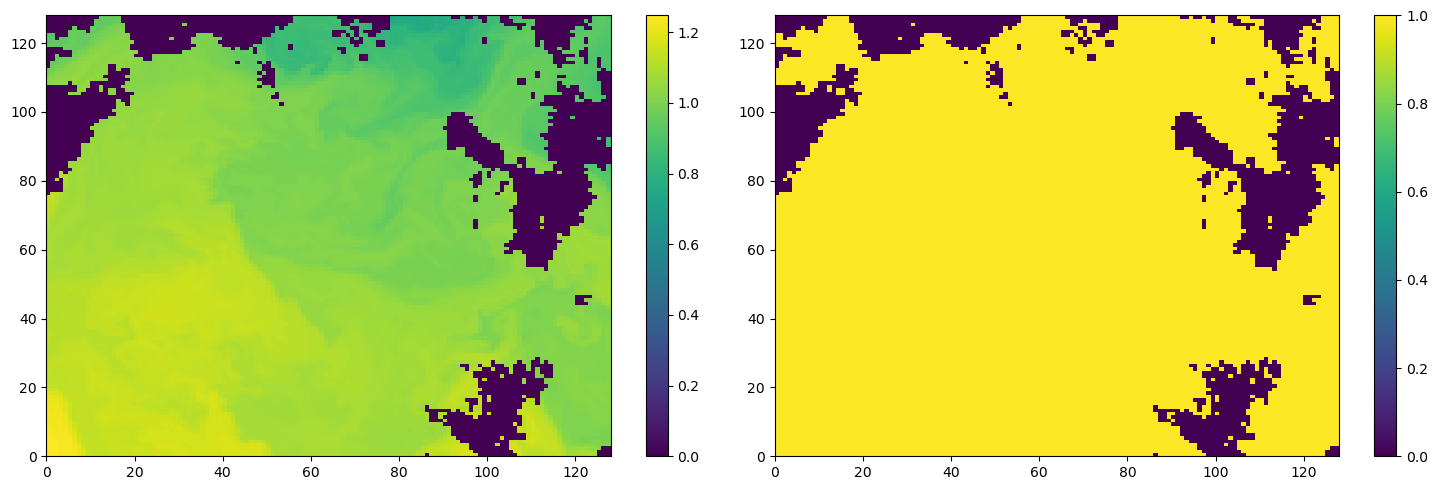

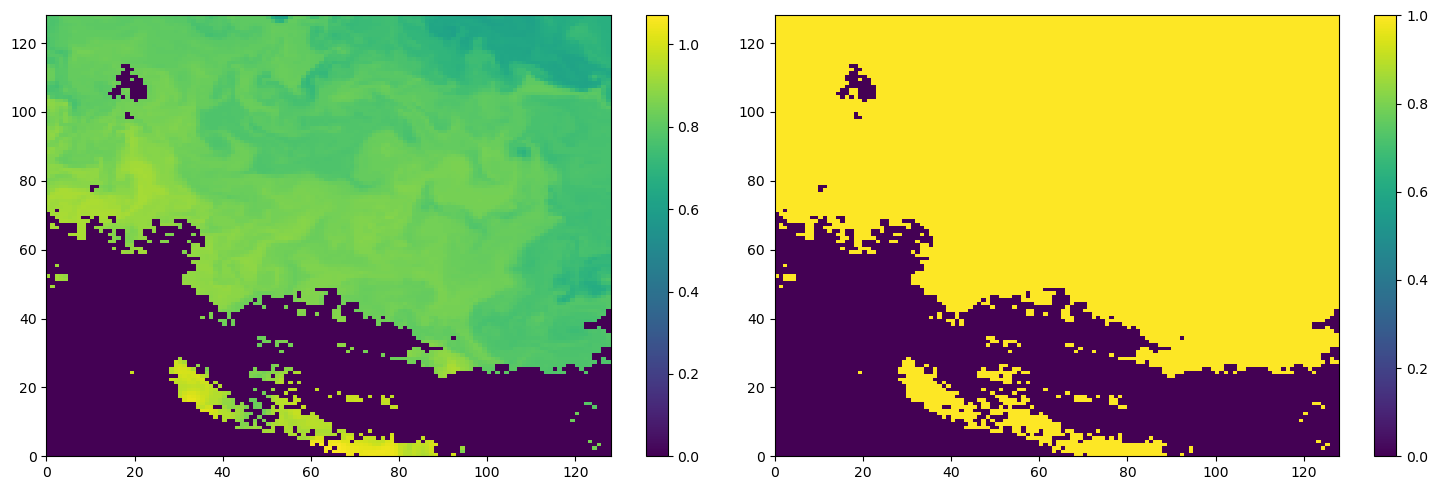

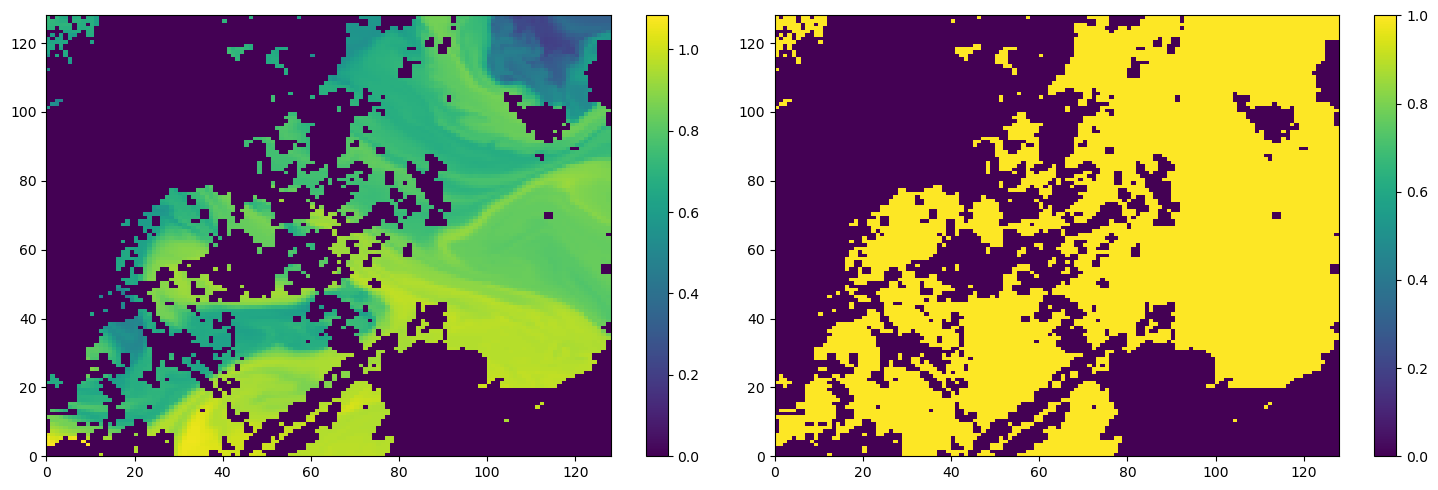

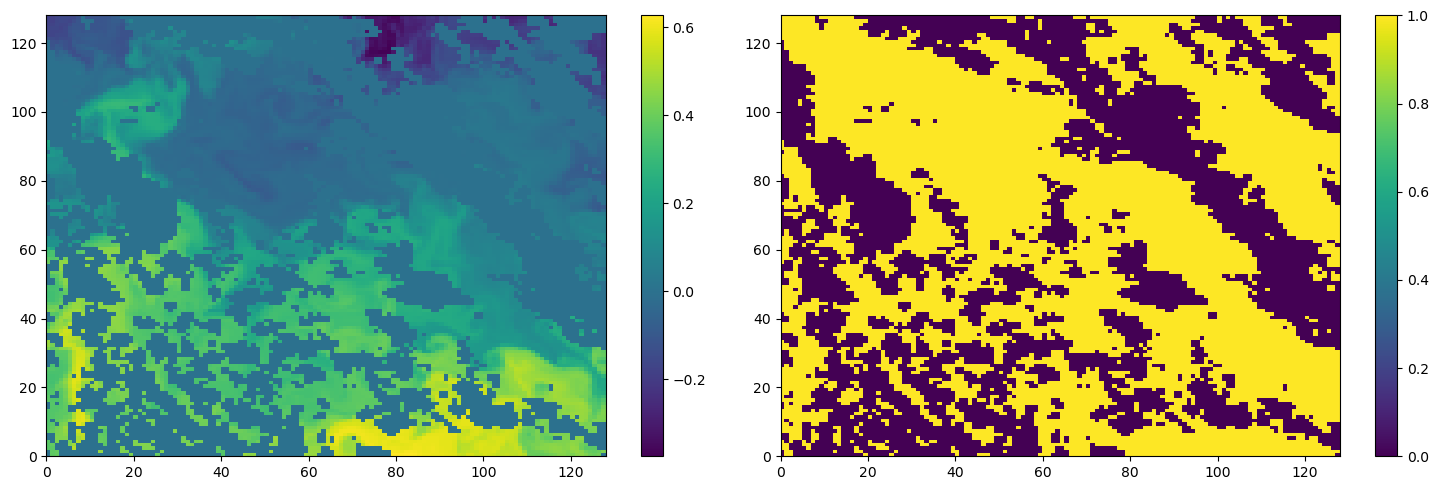

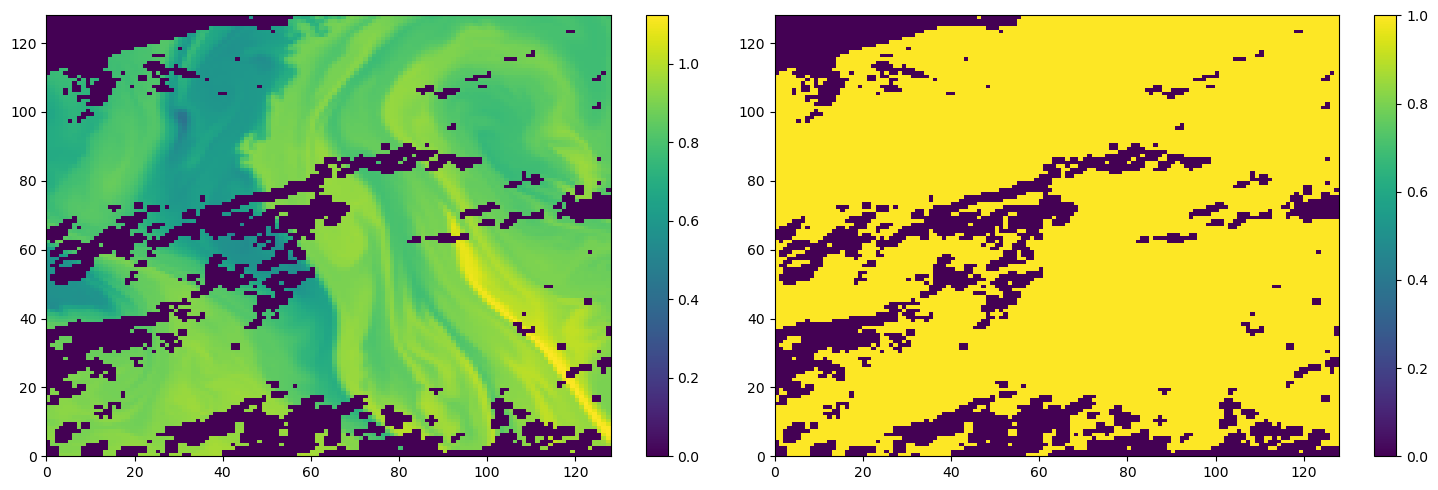

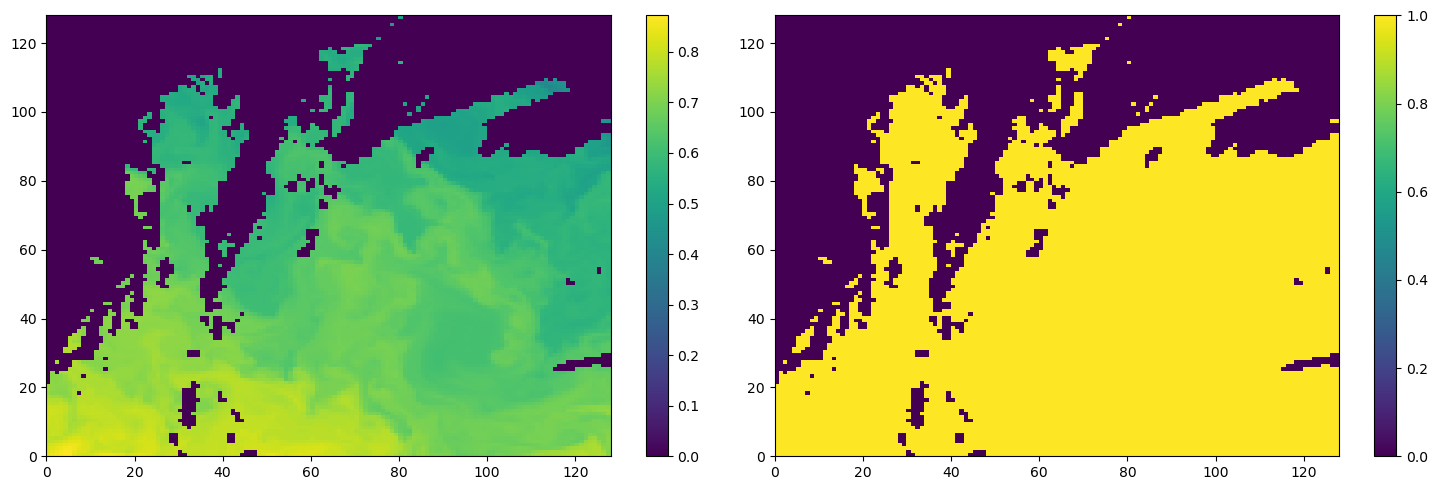

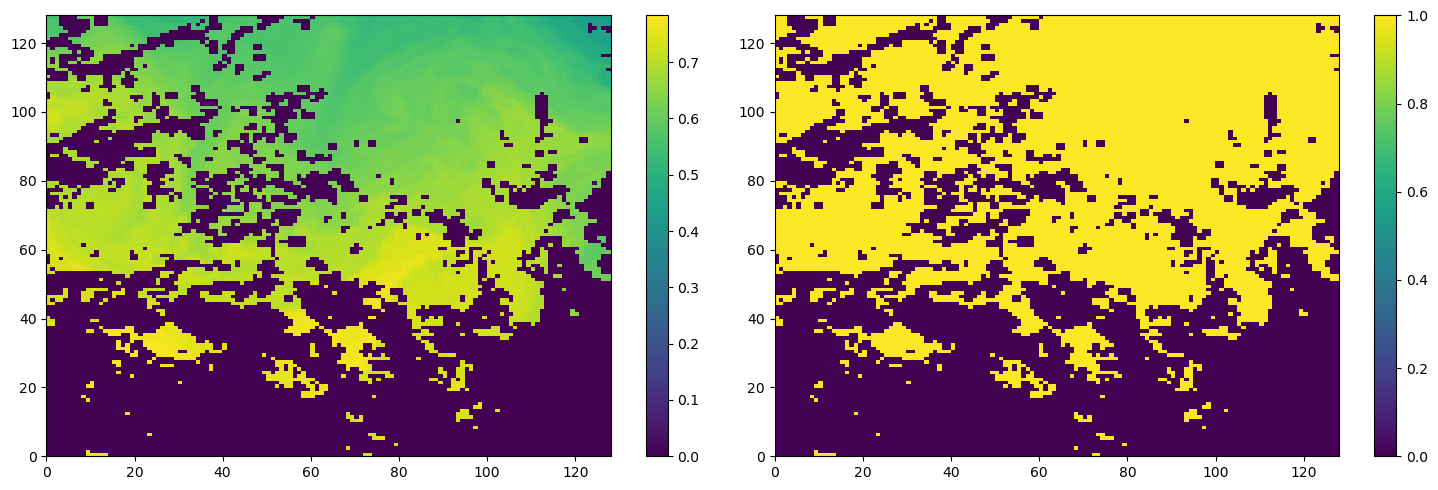

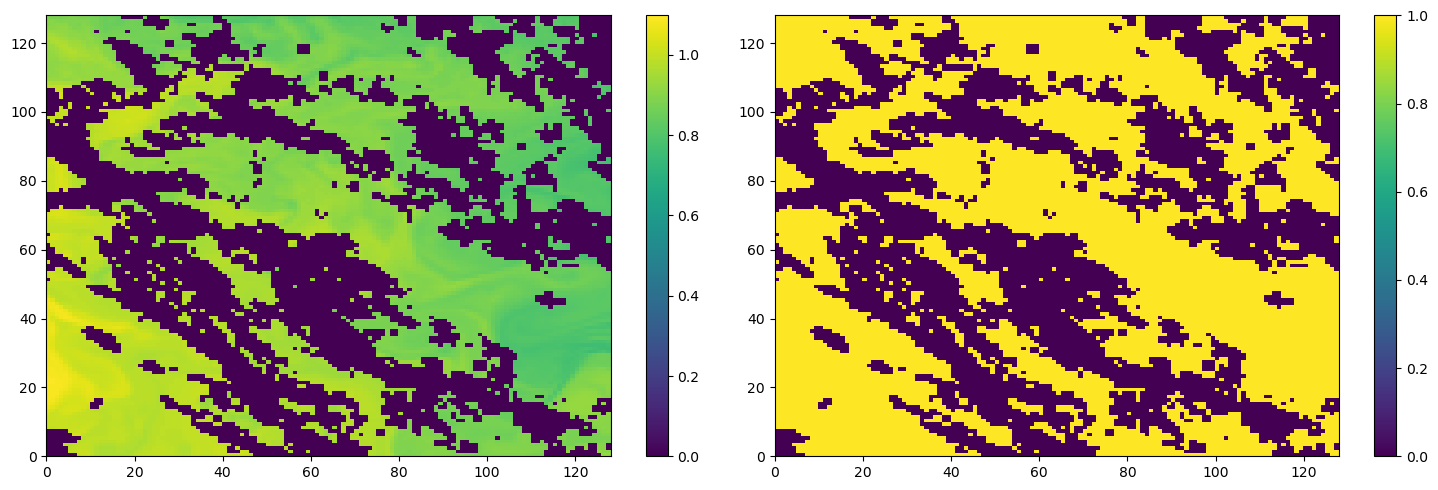

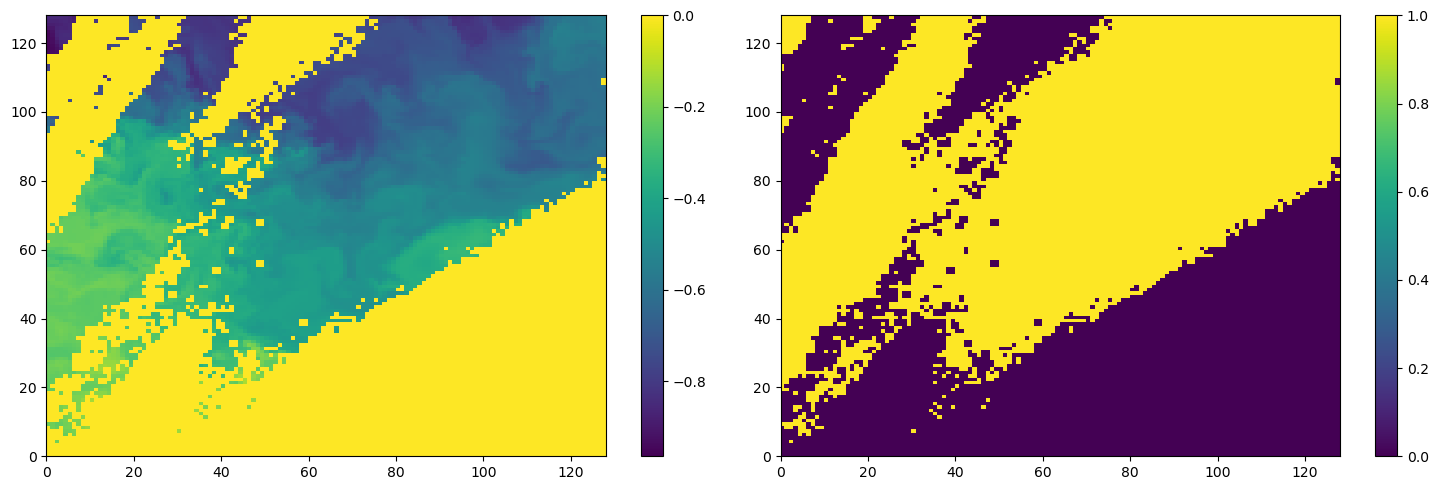

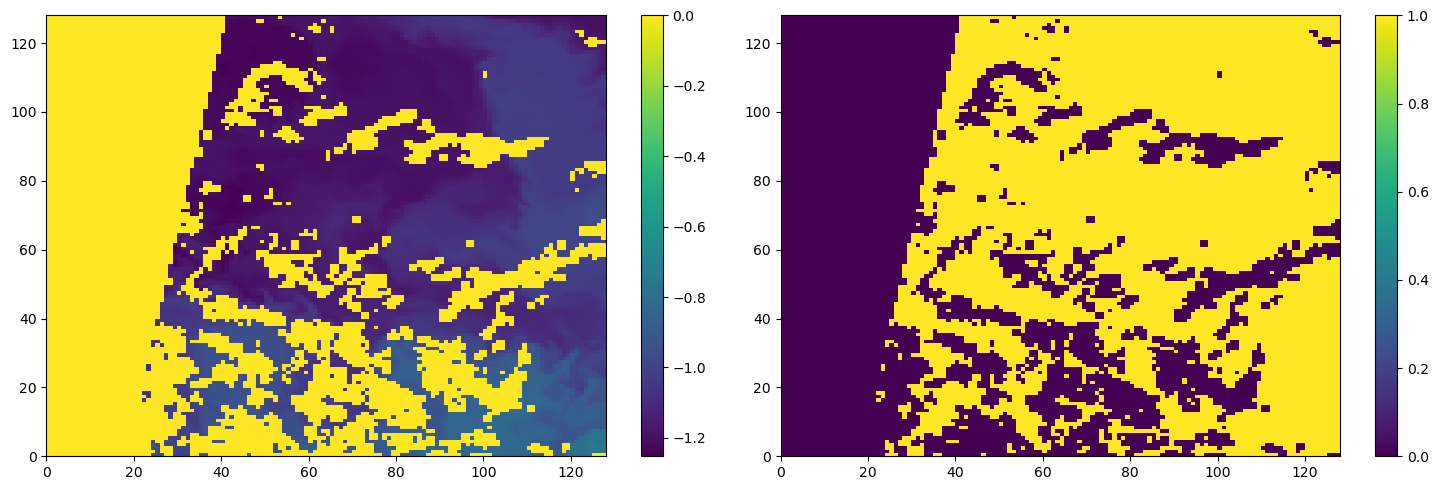

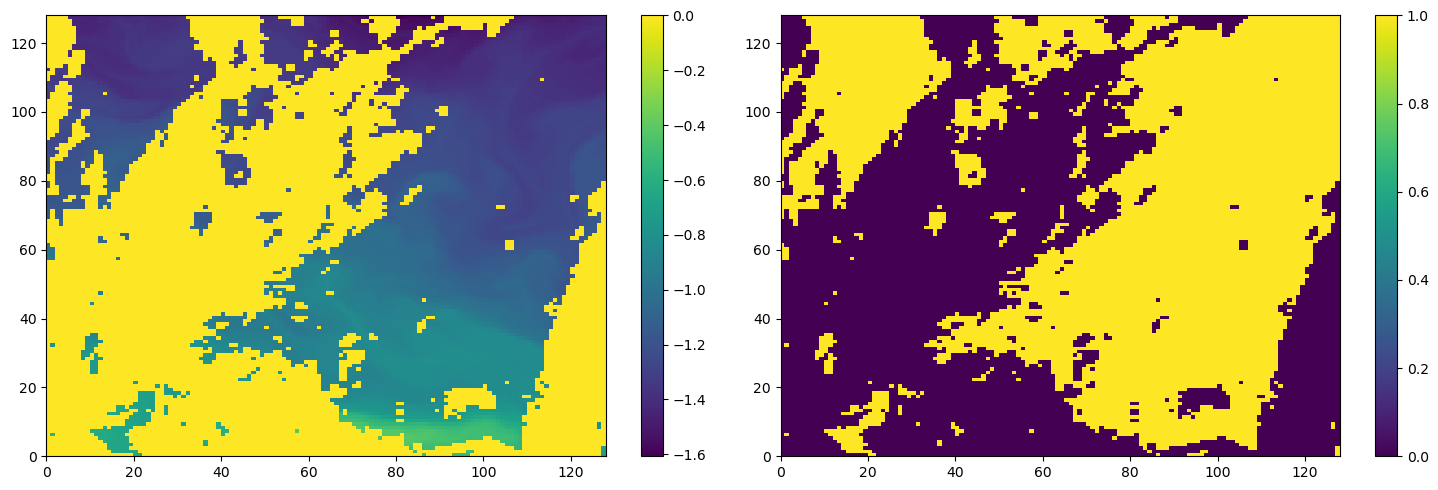

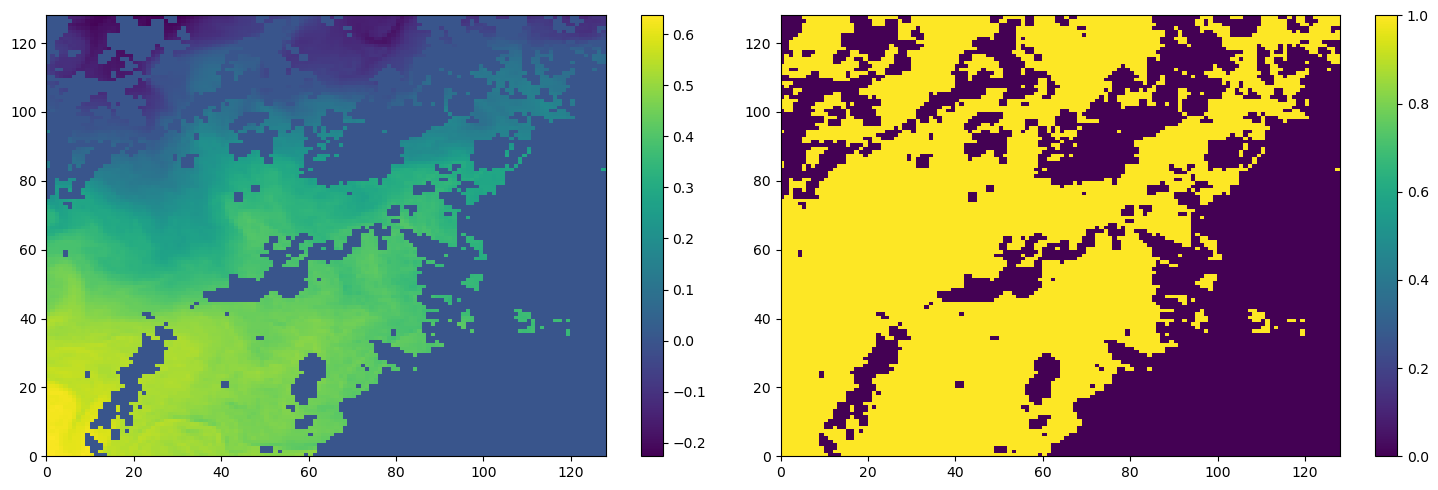

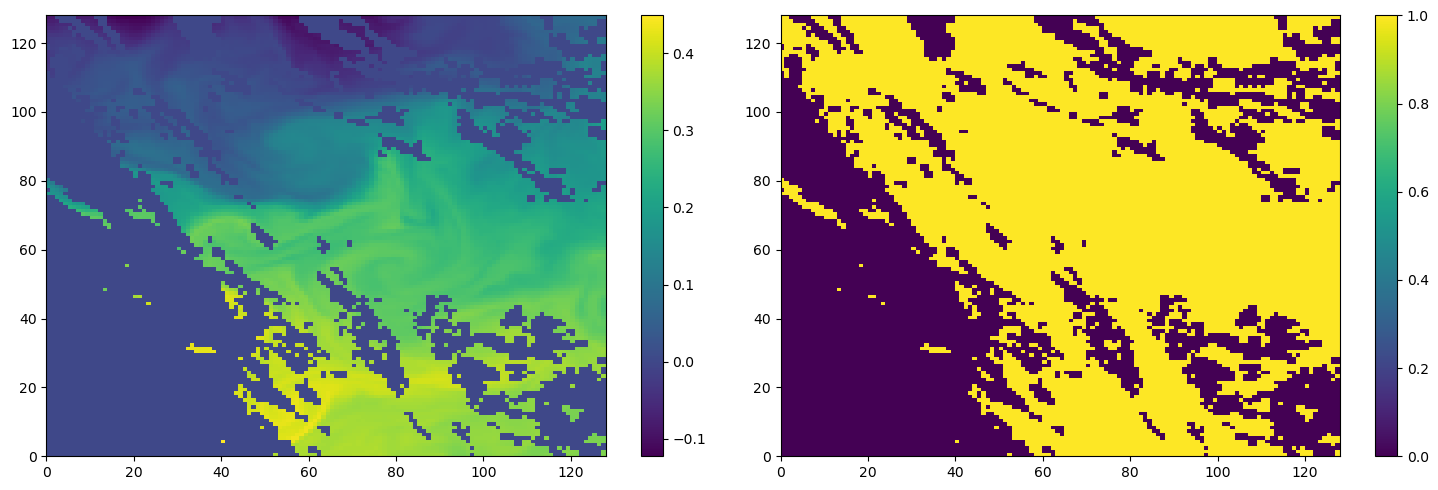

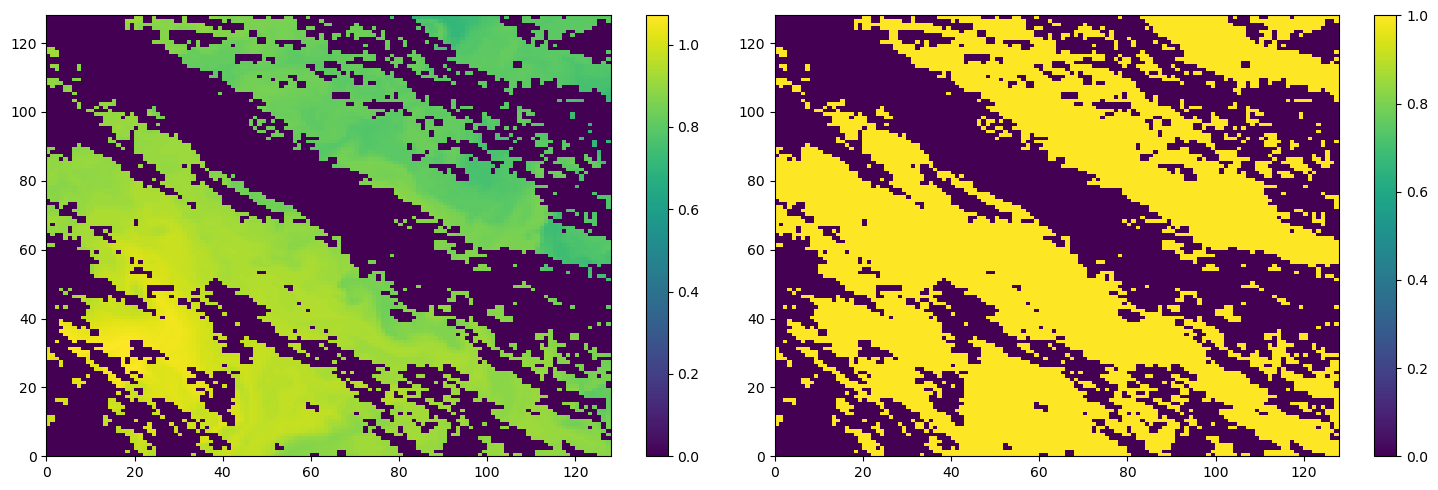

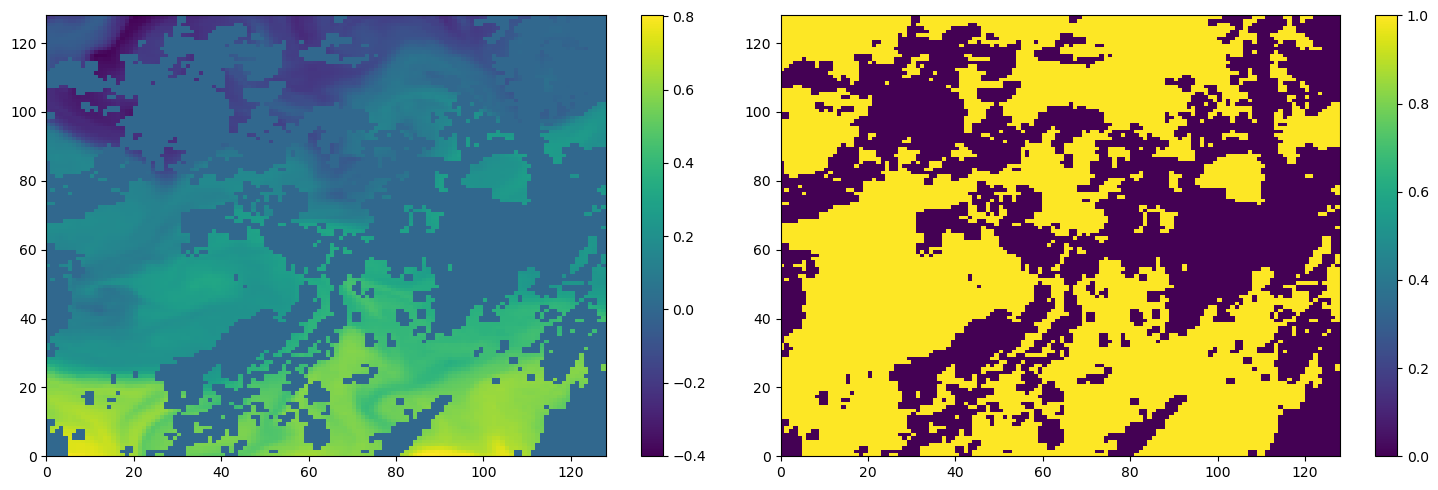

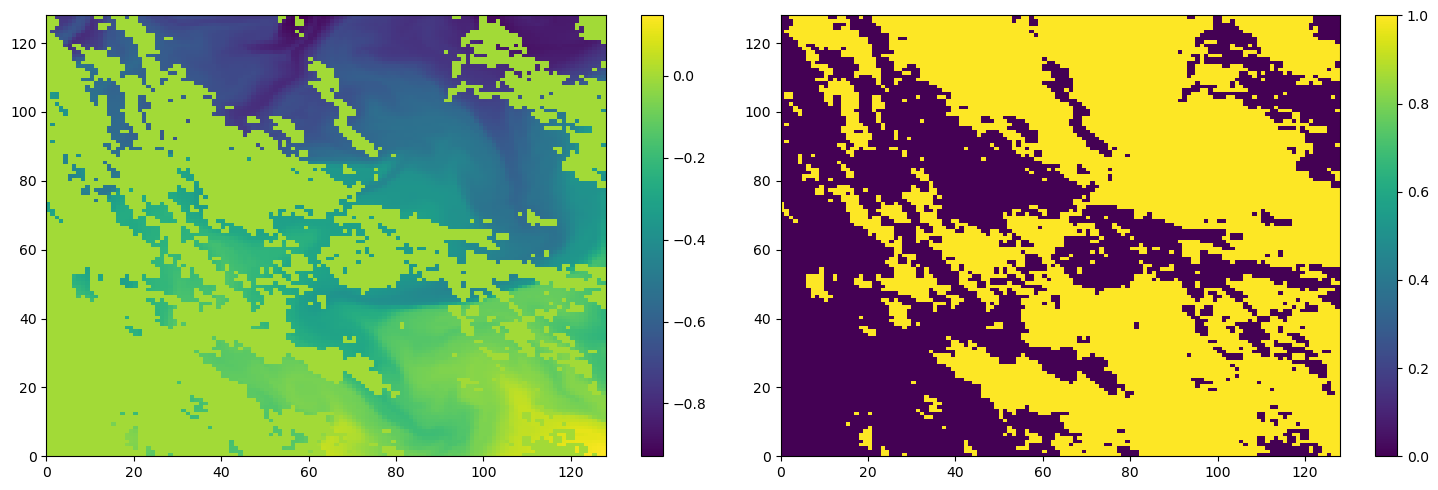

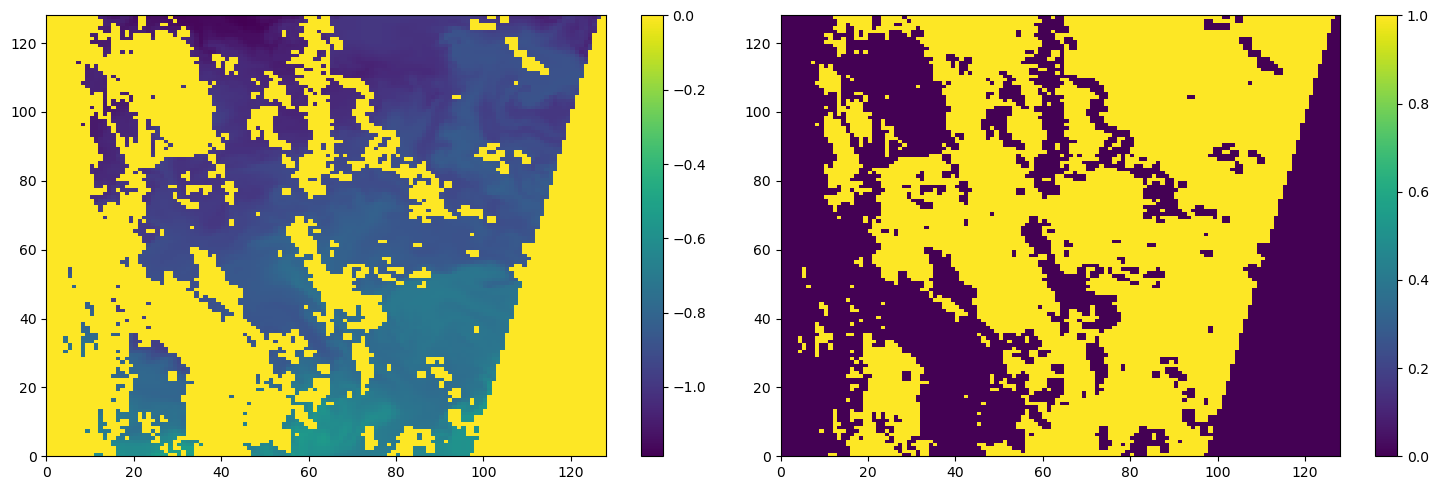

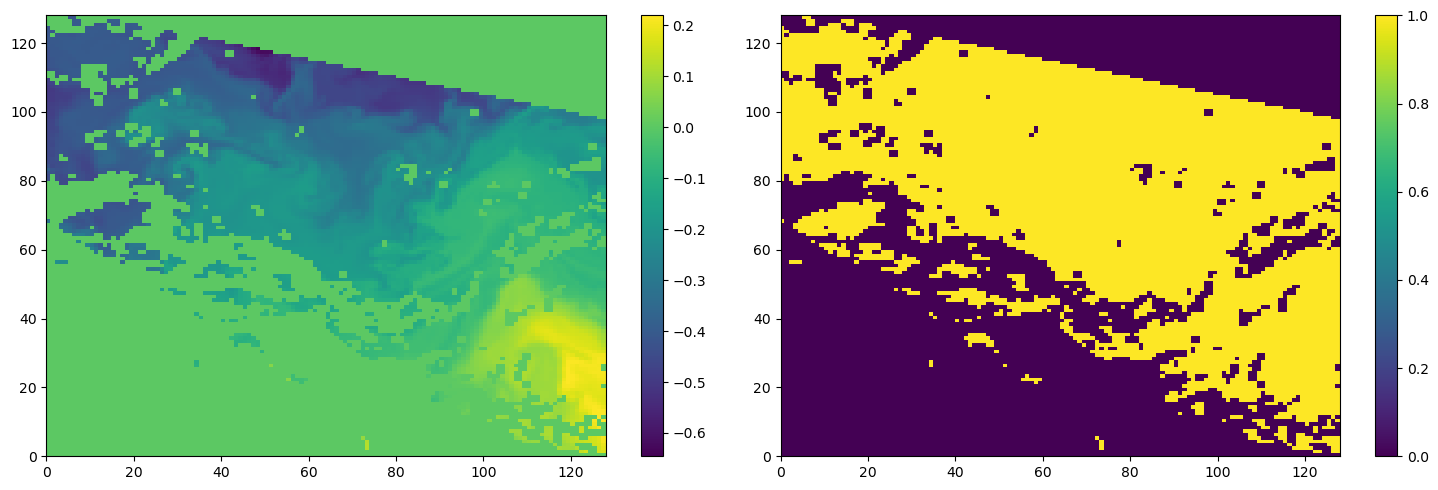

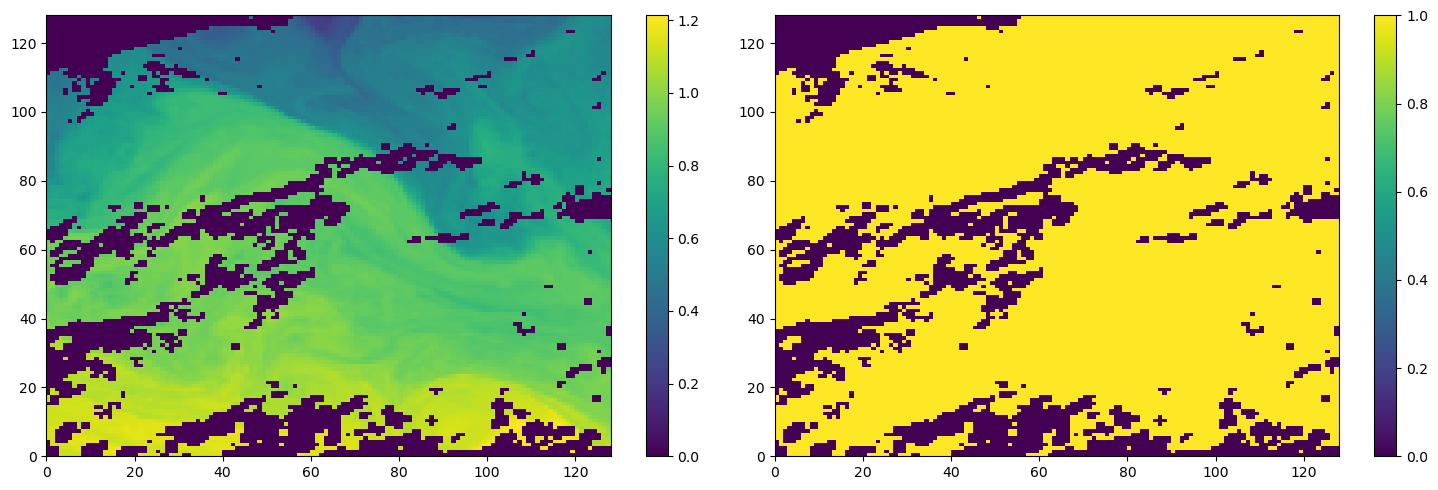

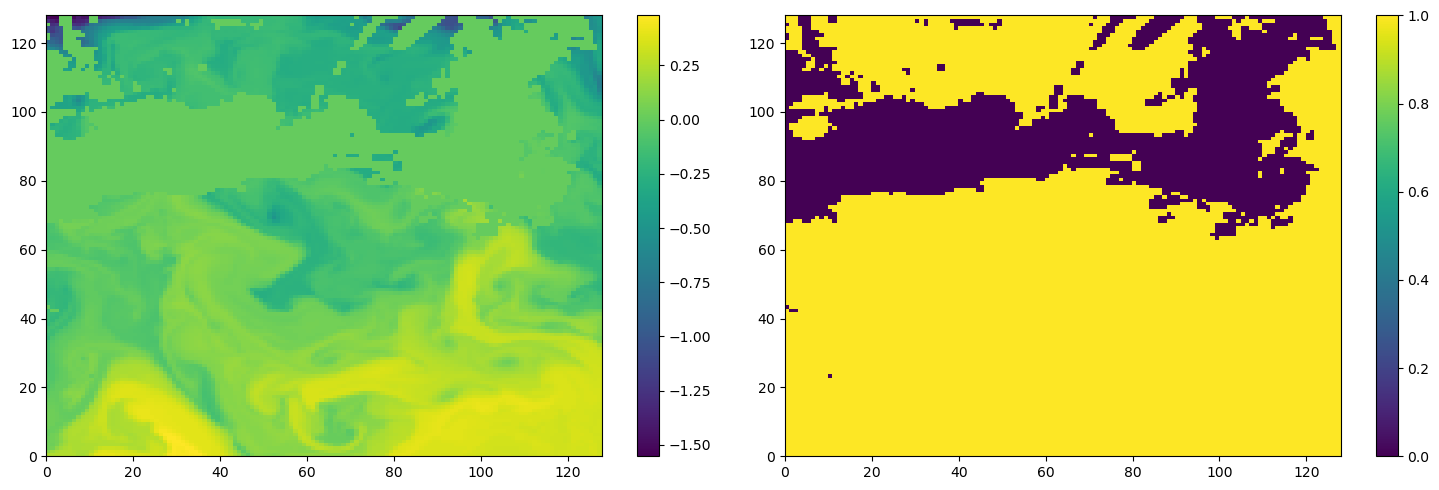

In [33]:
for i in range(len(y_train)):
    fig, axs = plt.subplots(len(y_train[0,0,0]),2,figsize=(15,5*len(y_train[0,0,0])))
    axs = axs.flatten()
    im0=axs[0].pcolor(y_train[i,:,:,0].squeeze())
    im1=axs[1].pcolor(A_train[i,:,:,0].squeeze())
    plt.colorbar(im0,ax=axs[0])
    plt.colorbar(im1,ax=axs[1])
    if len(y_train[0,0,0]) > 1:
        im2=axs[2].pcolor(y_train[i,:,:,1].squeeze())
        im3=axs[3].pcolor(A_train[i,:,:,1].squeeze())
        plt.colorbar(im2,ax=axs[2])
        plt.colorbar(im3,ax=axs[3]) 

    fig.tight_layout()
    plt.show()
    plt.close()